# scRNA-seq Analysis: PBMC 3k
## A complete single-cell RNA sequencing pipeline using Scanpy

This notebook walks through quality control, normalization, dimensionality 
reduction, clustering, and cell type annotation of 3,000 human peripheral 
blood mononuclear cells (PBMCs) from 10x Genomics.

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sc.settings.verbosity = 1 ## min output msgs
sc.settings.figdir = '../figures/'
%matplotlib inline

## Step 1: Load Data

In [4]:
adata = sc.datasets.pbmc3k()
print(adata)

  0%|          | 0.00/5.58M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


## Step 2: Quality Control

In [15]:
adata.var

,gene_ids
index,
MIR1302-10,ENSG00000243485
FAM138A,ENSG00000237613
OR4F5,ENSG00000186092
RP11-34P13.7,ENSG00000238009
RP11-34P13.8,ENSG00000239945
...,...
AC145205.1,ENSG00000215635
BAGE5,ENSG00000268590
CU459201.1,ENSG00000251180


In [17]:
adata.var_names

Index(['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8',
       'AL627309.1', 'RP11-34P13.14', 'RP11-34P13.9', 'AP006222.2',
       'RP4-669L17.10',
       ...
       'KIR3DL2-1', 'AL590523.1', 'CT476828.1', 'PNRC2-1', 'SRSF10-1',
       'AC145205.1', 'BAGE5', 'CU459201.1', 'AC002321.2', 'AC002321.1'],
      dtype='object', name='index', length=32738)

In [27]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')

In [39]:
mt_genes = adata.var['mt'].sum()

In [45]:
print(f"The number of mitochondrial genes in this set is {mt_genes}")

The number of mitochondrial genes in this set is 13


In [47]:
adata.var[adata.var['mt']==True]

,gene_ids,mt
index,,
MT-ND1,ENSG00000198888,True
MT-ND2,ENSG00000198763,True
MT-CO1,ENSG00000198804,True
MT-CO2,ENSG00000198712,True
MT-ATP8,ENSG00000228253,True
MT-ATP6,ENSG00000198899,True
MT-CO3,ENSG00000198938,True
MT-ND3,ENSG00000198840,True
MT-ND4L,ENSG00000212907,True


In [51]:
sc.pp.calculate_qc_metrics(adata, qc_vars = ['mt'], percent_top = None, log1p = False, inplace = True)

In [53]:
adata.obs.head()

,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt
index,,,,
AAACATACAACCAC-1,781,2421.0,73.0,3.015283
AAACATTGAGCTAC-1,1352,4903.0,186.0,3.793596
AAACATTGATCAGC-1,1131,3149.0,28.0,0.889171
AAACCGTGCTTCCG-1,960,2639.0,46.0,1.743085
AAACCGTGTATGCG-1,522,981.0,12.0,1.223242


### QC Visualization

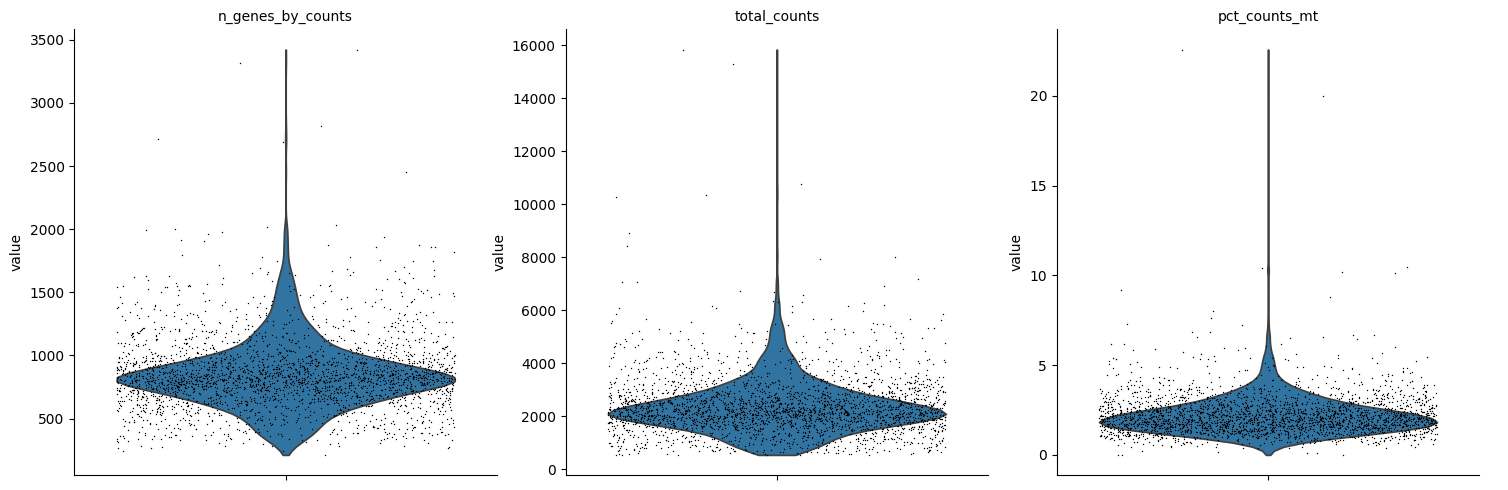

In [72]:
sc.pl.violin(
    adata,
    keys = ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter = 0.4,
    multi_panel = True
)

### QC Observations

**n_genes_by_counts**
- Most cells have between 500-1000 genes detected
- Cells with very few genes (<200) are likely empty droplets
- Cells with very high genes (>2500) are likely doublets — two cells captured together

**total_counts**
- Most cells have 1500-2500 RNA molecules
- Cells with 7000-16000 counts are suspicious — likely doublets

**pct_counts_mt**
- Most cells have 2-3% mitochondrial RNA — this is normal
- Cells above 5% are likely dying or damaged — they leak regular RNA 
  but retain mitochondrial RNA longer

**Thresholds chosen:**
- Keep cells with n_genes between 200 and 2500
- Keep cells with pct_counts_mt below 5%

Note: These thresholds are not universal facts — they are conventions 
based on this dataset. Different tissues or experiments may require 
different cutoffs.|

In [75]:
print(f"Cells before filtering: {adata.n_obs}")

Cells before filtering: 2700


In [82]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs.n_genes_by_counts < 2500, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]

print(f"Cells after filtering: {adata.n_obs}")

Cells after filtering: 2638
